**TITLE: Amazon Prime Video EDA : AI-Driven Movie Success Prediction using Merged Datasets**

**Problem Statement**

The entertainment industry generates a large amount of movie-related data, but it is often spread across multiple datasets such as movie details and credits. This makes it difficult to analyze the data effectively and extract meaningful insights. Additionally, predicting whether a movie will be successful is a complex task influenced by various factors like ratings, votes, and runtime.

This project aims to merge multiple datasets, analyze the data using exploratory data analysis (EDA), and build a machine learning model to predict movie success, enabling data-driven decision-making

**SUMMARY**
The project, “Amazon Prime Video Analytics: EDA & AI-Driven Movie Success Prediction using Merged Datasets”, focuses on analyzing movie data by combining multiple datasets and using machine learning to predict whether a movie will be successful.

In this project, we first merge datasets containing movie details and credits, then perform exploratory data analysis (EDA) to understand patterns, and finally build a machine learning model to predict movie success.

**KEY INSIGHTS**:
*   **Data Merging & Preparation**: We take data from different files and join them into one complete table so that all information about a movie is available in one place.
*   **Exploratory Data Analysis (EDA)**: We study the data using graphs to understand which movies have higher ratings, how votes and runtime affect success and whether there are any unusual values (outliers). This helps us discover patterns, understand relationships,make better decisions before modeling.
*   **Machine Learning for Prediction**: We train a model using past movie data so that it can predict if a new movie will be successful. Create a target variable (success),train the model (Logistic Regression)and evaluate accuracy.

**Conclusion**

This project shows how merging datasets and performing EDA helps in understanding movie data and identifying key patterns. It highlights that movies with higher ratings and votes are more likely to succeed. Using machine learning, we built a model that can predict movie success, demonstrating the power of data-driven decision-making in the entertainment industry.





https://github.com/chaitramcse7-beep/Amazon-Prime-EDA-ML-Project

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Here, we are importing the required libraries:


*   pandas → to handle data
*   numpy → for numerical operations
*   matplotlib & seaborn → for graphs and visualizations

**Load Dataset**

In [ ]:
credits = pd.read_csv('/content/credits.csv')
titles = pd.read_csv('/content/titles.csv')

We load both datasets into the notebook credits contains cast & crew details
titles contains movie information

**View Data**

In [ ]:
#Displays first 5 rows
credits.head()
titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


**Data Info**

In [ ]:
credits.info()
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   in

Shows columns, data types, and missing values and helps in planning data cleaning.

**Merge Data**

In [ ]:
df = pd.merge(titles, credits, on='id')
df.head()


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR


In [ ]:
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

Total rows: 124347
Total columns: 19


In [ ]:
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'person_id', 'name', 'character', 'role'],
      dtype='object')


**Check Missing Values**

In [ ]:
# Step 1: Check missing values for all columns
missing_values = df.isnull().sum()

# Step 2: Display only columns with missing values
print("Columns with missing values:\n")
print(missing_values[missing_values > 0])

Columns with missing values:

description              91
age_certification     67640
seasons              116194
imdb_id                5303
imdb_score             6051
imdb_votes             6075
tmdb_popularity          15
tmdb_score            10265
character             16307
dtype: int64


**Fill Missing Values**

In [ ]:
# Numeric columns → fill missing with mean
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Object columns → fill missing with "Unknown"
object_cols = ['description', 'age_certification', 'imdb_id', 'character']
# Object columns → fill missing values without inplace
for col in object_cols:
    df[col] = df[col].fillna("Unknown")

# Verify no missing values remain
print("\nMissing values after filling:\n")
print(df.isnull().sum())


Missing values after filling:

id                      0
title                   0
type                    0
description             0
release_year            0
age_certification       0
runtime                 0
genres                  0
production_countries    0
seasons                 0
imdb_id                 0
imdb_score              0
imdb_votes              0
tmdb_popularity         0
tmdb_score              0
person_id               0
name                    0
character               0
role                    0
dtype: int64


**IMDb Score Box Plot**

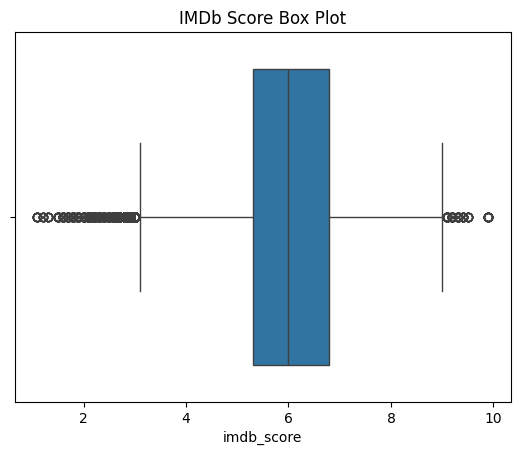

In [25]:
sns.boxplot(x=df['imdb_score'])
plt.title("IMDb Score Box Plot")
plt.show()

Shows spread and outliers in ratings. Some movies have extreme ratings.

**Runtime Box Plot**

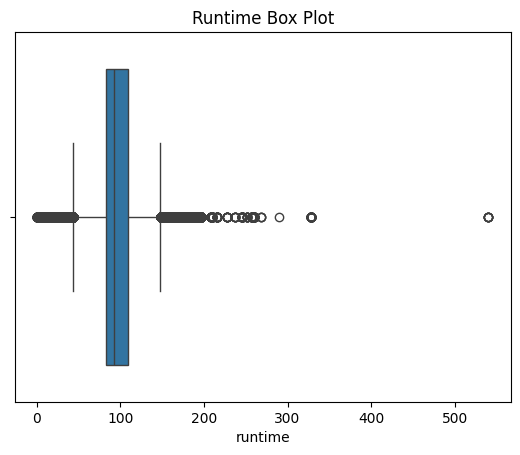

In [26]:
sns.boxplot(x=df['runtime'])
plt.title("Runtime Box Plot")
plt.show()

Identifies unusually long or short movies.

**IMDb Votes Box Plot**

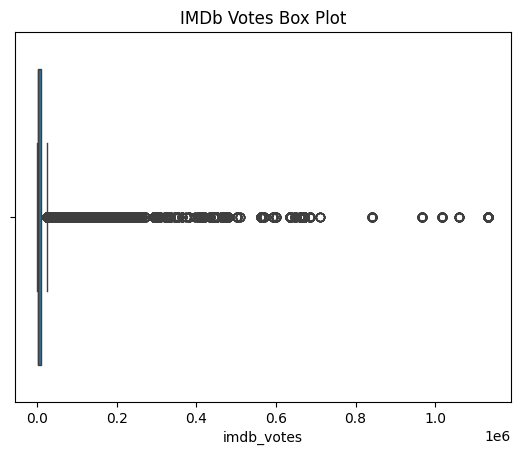

In [27]:
sns.boxplot(x=df['imdb_votes'])
plt.title("IMDb Votes Box Plot")
plt.show()

Shows extreme popularity differences.

**TMDB Score Box Plot**

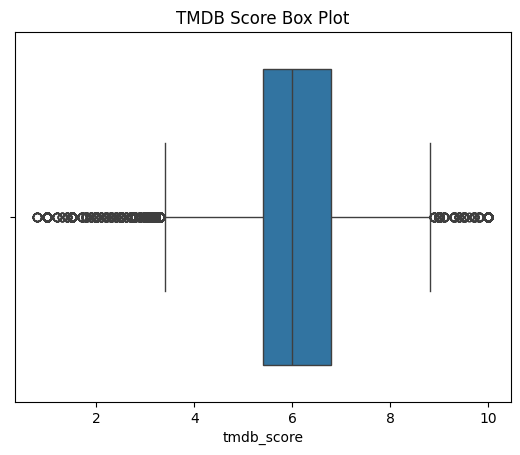

In [28]:
sns.boxplot(x=df['tmdb_score'])
plt.title("TMDB Score Box Plot")
plt.show()

Helps detect variation in ratings.

**Content Type**

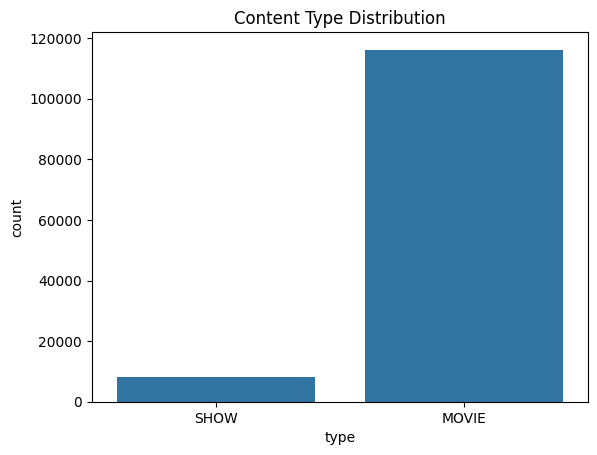

In [29]:
sns.countplot(x=df['type'])
plt.title("Content Type Distribution")
plt.show()

Shows number of movies vs shows.

**Age Certification**

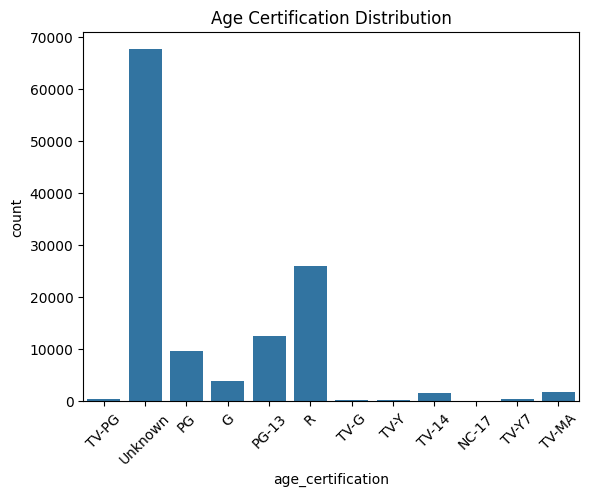

In [30]:
sns.countplot(x=df['age_certification'])
plt.xticks(rotation=45)
plt.title("Age Certification Distribution")
plt.show()

Age certification indicates the appropriate audience for movies. For example, PG means parental guidance is suggested, while categories like R and TV-MA are meant for mature audiences.

**Top Genres**

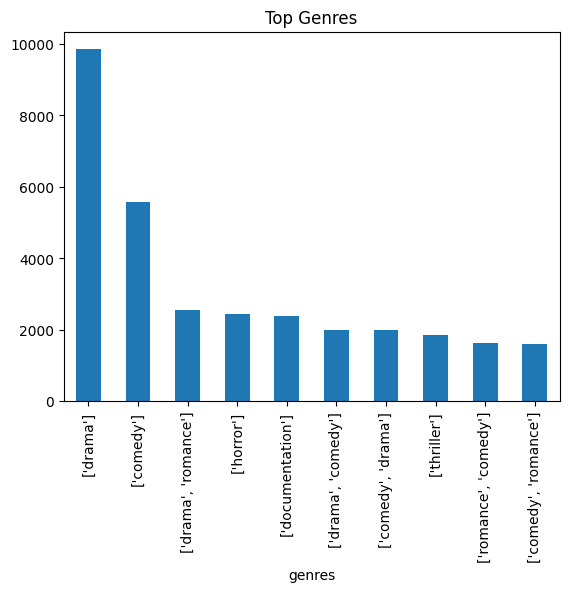

In [31]:
df['genres'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

Shows most common genres.

**Votes vs Score**

/tmp/ipykernel_11294/3992525455.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('runtime_bin')['imdb_score'].mean().plot(kind='bar')


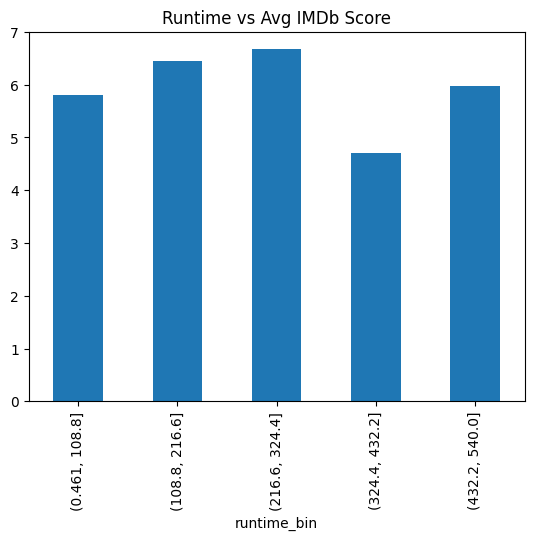

In [36]:
df['runtime_bin'] = pd.cut(df['runtime'], bins=5)

df.groupby('runtime_bin')['imdb_score'].mean().plot(kind='bar')
plt.title("Runtime vs Avg IMDb Score")
plt.show()

Instead of scatter plot, we used a density-based visualization to better understand the relationship between votes and ratings

**Runtime vs Score**

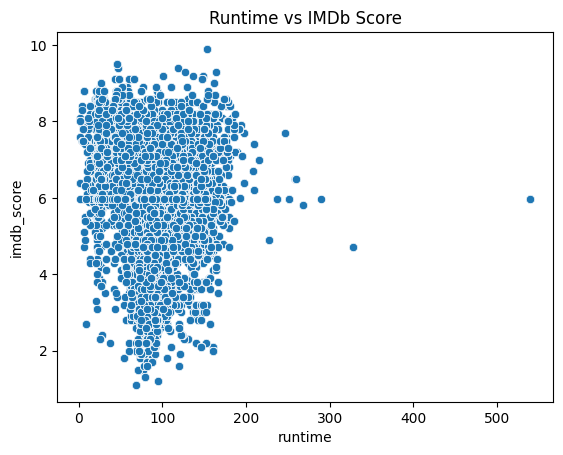

In [37]:
sns.scatterplot(x=df['runtime'], y=df['imdb_score'])
plt.title("Runtime vs IMDb Score")
plt.show()

Checks if longer movies have better ratings.

**Correlation Heatmap**

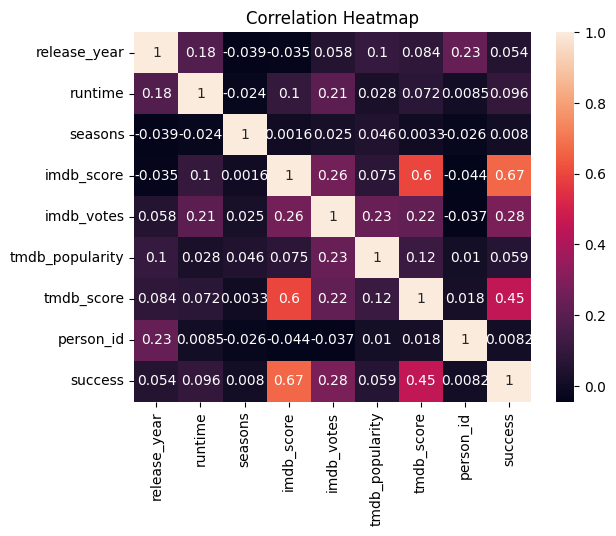

In [38]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Each box compares two columns
The number inside shows the relationship (correlation)
Values range from:

+1 → strong positive relation (both increase together)

0 → no relation

-1 → negative relation (one increases, other decreases)

Dark red → strong positive relation

Dark blue → strong negative relation

Light color → weak relation

Example:

imdb_votes & imdb_score = 0.6

Means: movies with more votes tend to have higher ratings

**Score Distribution**

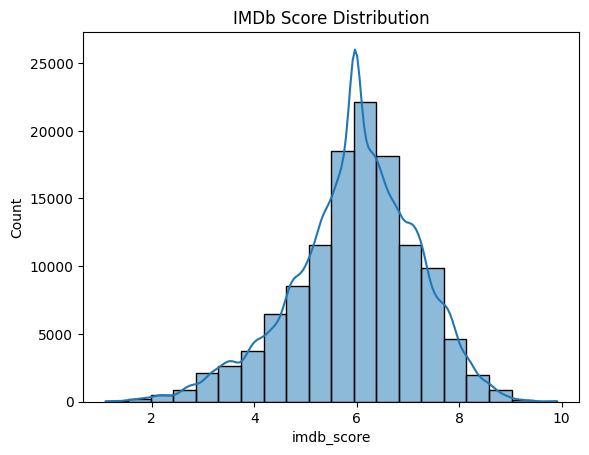

In [ ]:
sns.histplot(df['imdb_score'], bins=20, kde=True)
plt.title("IMDb Score Distribution")
plt.show()

This chart shows how movie ratings are distributed. Most movies fall in the mid-range, indicating average ratings are more common.

**Runtime Distribution**

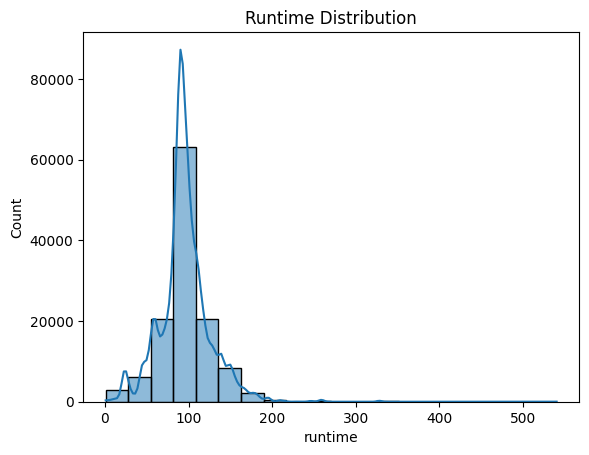

In [ ]:
sns.histplot(df['runtime'], bins=20, kde=True)
plt.title("Runtime Distribution")
plt.show()

This shows the spread of movie durations. Most movies have a standard runtime, while a few are very short or long.

**Release Year Trend**

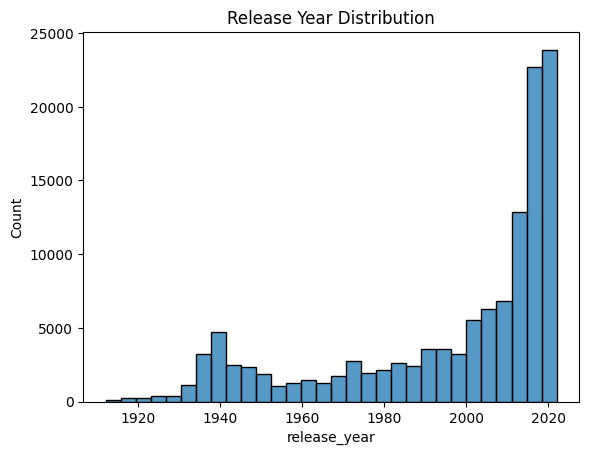

In [ ]:
sns.histplot(df['release_year'], bins=30)
plt.title("Release Year Distribution")
plt.show()

This shows how movie production varies over time. It helps identify growth in content production.

**IMDb Votes Histogram**

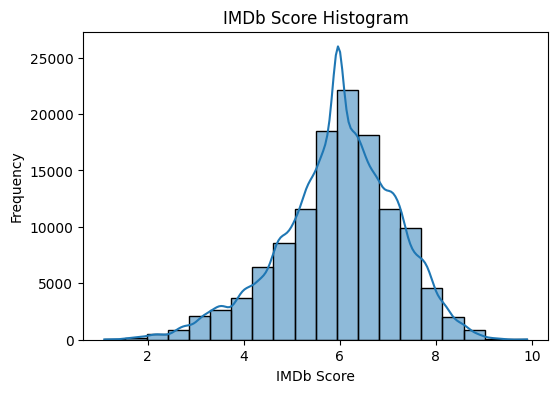

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(df['imdb_score'], bins=20, kde=True)
plt.title("IMDb Score Histogram")
plt.xlabel("IMDb Score")
plt.ylabel("Frequency")
plt.show()

This histogram shows how IMDb scores are distributed across all movies in the dataset. The bars represent the number of movies falling within specific rating ranges, while the smooth curve helps us understand the overall trend more clearly. From the graph, we can observe that most movies have ratings between 6 and 7, indicating that average-rated movies are more common, while very high and very low ratings are less frequent.

**Release Year Histogram**

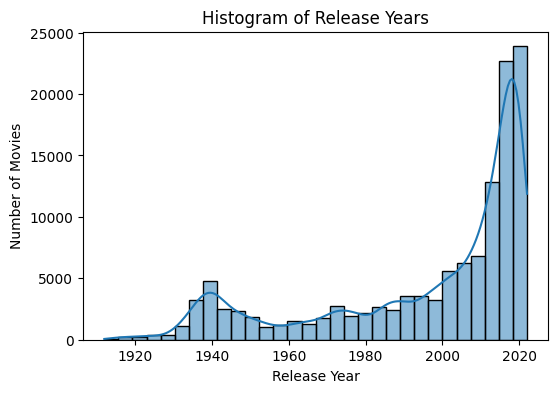

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['release_year'], bins=30, kde=True)
plt.title("Histogram of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.show()

This histogram shows how movies are distributed across different years. It helps us understand how many movies were released in each time period. From the graph, we can see whether the number of movies has increased or decreased over time.

**Machine Learning**

**Logistic Regression**

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

model1 = LogisticRegression()

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))

Logistic Regression Accuracy: 0.8437072778447929
Confusion Matrix:
 [[18781   882]
 [ 3005  2202]]


Logistic Regression is used for classification (0 or 1)

It learns patterns from training data

Then predicts movie success

**Random Forest**

In [40]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(n_estimators=100, random_state=42)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))

Random Forest Accuracy: 0.9980699638118214
Confusion Matrix:
 [[19652    11]
 [   37  5170]]


Random Forest uses multiple decision trees

Combines their results for better accuracy

**Compare Accuracy**

In [41]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred1))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred2))

Logistic Regression Accuracy: 0.8437072778447929
Random Forest Accuracy: 0.9980699638118214


*   We use Logistic Regression, a classification algorithm
*   model.fit() trains the model using training data

**IMDb Score Prediction (Regression)**

In [43]:
from sklearn.model_selection import train_test_split

# Target variable (continuous)
y_reg = df['imdb_score']

# Using same features
X_reg = df[['imdb_votes', 'runtime', 'tmdb_score']]

# Split data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Training shape:", X_train_r.shape)
print("Testing shape:", X_test_r.shape)

Training shape: (99477, 3)
Testing shape: (24870, 3)


The dataset was split into training and testing sets, where 80% of the data is used for training and 20% for testing. The shape output shows the number of samples and features used in each set.